In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
bank_trans= pd.read_csv("bank_transactions_data.csv")


In [ ]:
bank_trans.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


In [ ]:
bank_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
bank_trans.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


**Exploratory Data Analysis**

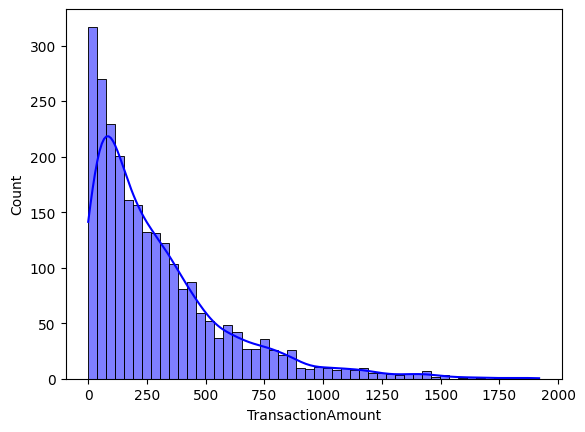

In [ ]:

sns.histplot(bank_trans['TransactionAmount'], bins=50, kde=True, color='blue')

plt.show()

Outlier Identification: High-value transactions (e.g., >$1,500) are rare and could indicate potential fraud, as they deviate from the norm.

/tmp/ipython-input-4285967386.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TransactionType', y='TransactionAmount', data=bank_trans, palette=['green', 'yellow'])


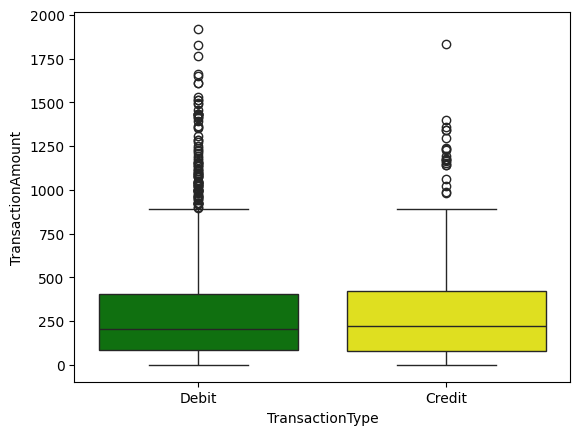

In [ ]:
sns.boxplot(x='TransactionType', y='TransactionAmount', data=bank_trans, palette=['green', 'yellow'])

plt.show()

Fraud Insight:
Large debit transactions might indicate unauthorized withdrawals.
Credit outliers could suggest fraudulent transactions, illegal activities or money laundering.

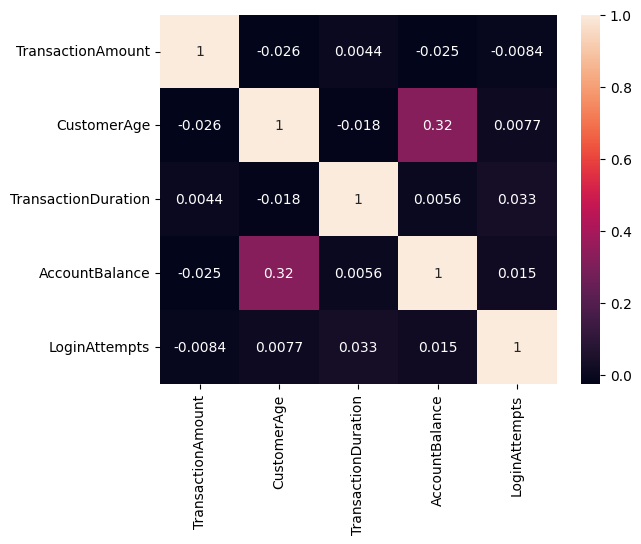

In [ ]:
sns.heatmap(bank_trans[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']].corr(),
            annot=True)
plt.show()

Most correlations are weak (close to 0), meaning features are largely independent. The strongest correlation is between CustomerAge and AccountBalance (0.32), that means older customers tend to have higher balances. TransactionAmount and LoginAttempts show low correlations that implies they don’t move together, so they can each provide unique signals for detecting anomalies in fraud analysis.

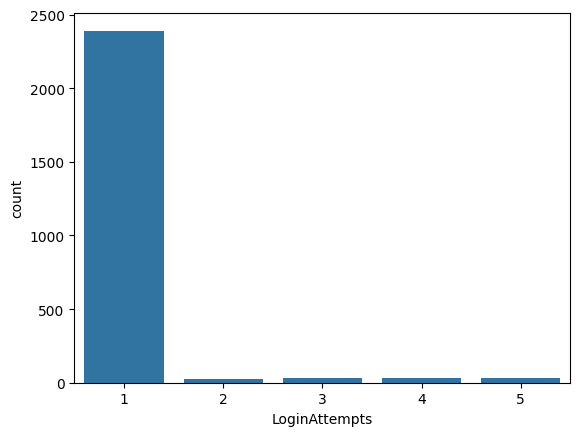

In [ ]:
sns.countplot(x='LoginAttempts', data=bank_trans)
plt.show()

Fraud Insight:
• Transactions with >1 login attempt might indicate account takeover attempts.
• Rare high values (e.g., 5 attempts) are red flags.

<Axes: xlabel='Channel', ylabel='TransactionAmount'>

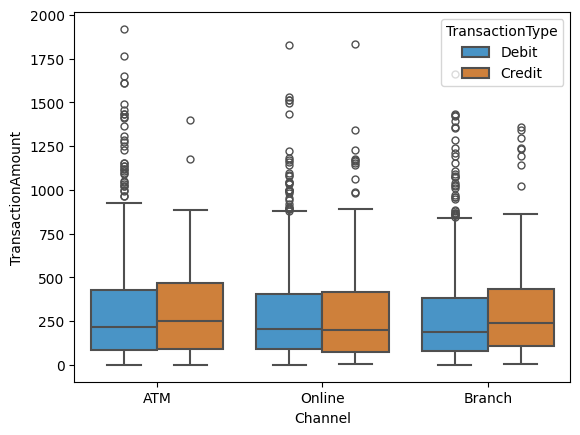

In [ ]:
sns.boxplot(x='Channel', y='TransactionAmount', hue='TransactionType',
            data=bank_trans, palette=['#3498db', '#e67e22'], linewidth=1.5, fliersize=5)

Distribution of transaction amounts across Channel categories, split by TransactionType (Debit/Credit).

Fraud Insight:

• Higher medians or outliers in Online transactions might suggest e-commerce fraud.
• ATM transactions with large debits could indicate fraud withdrawals

Anomaly Detection

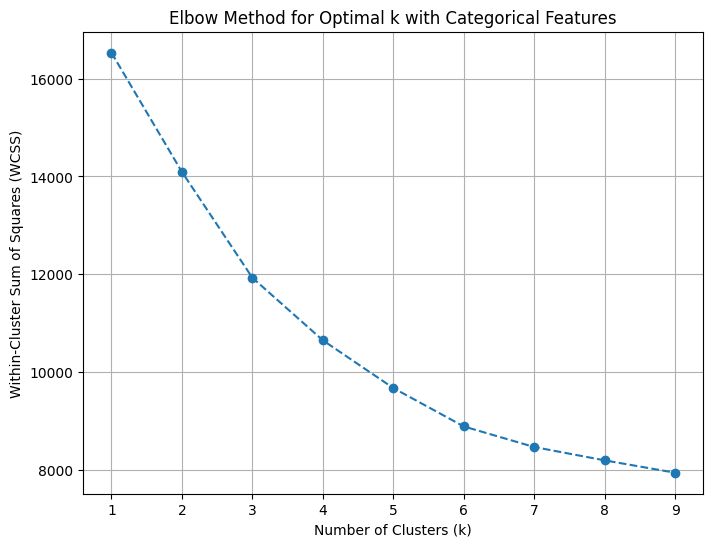

In [ ]:
numerical_features = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 'LoginAttempts', 'CustomerAge']
categorical_features = ['TransactionType', 'Location', 'Channel']
# Numerical data preprocessing
X_num = bank_trans[numerical_features]
X_num = X_num.fillna(X_num.median())  # Impute with median
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
# Categorical data preprocessing (one-hot encoding)
X_catgl = pd.get_dummies(bank_trans[categorical_features], drop_first=True)  # drop_first to avoid multicollinearity
                        # Combine numerical and categorical features
X_combined = np.hstack((X_num_scaled, X_catgl.values))

# Calculate WCSS for a range of k values (elbow method)
wcss = []
k_range = range(1, 10)  # Test k from 1 to 10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_combined)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k with Categorical Features')
plt.grid(True)
plt.show()

In [ ]:
# Fit K-means with k=4
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X_combined)

# Assign clusters and calculate distance to cluster centroid
bank_trans['Cluster'] = kmeans.labels_
bank_trans['DistanceToCentroid'] = np.linalg.norm(X_combined - kmeans.cluster_centers_[kmeans.labels_], axis=1)

# Identify potential frauds based on distance threshold (98th percentile)
threshold = bank_trans['DistanceToCentroid'].quantile(0.98)
bank_trans['PotentialFraud'] = bank_trans['DistanceToCentroid'] > threshold
fraud_df = bank_trans[bank_trans['PotentialFraud']].copy()
print('Total Potential Frauds',fraud_df.shape[0] )
fraud_df

Total Potential Frauds 51


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster,DistanceToCentroid,PotentialFraud
7,TX000008,AC00069,171.42,08-05-2023 17:47,Credit,Indianapolis,D000500,92.214.76.157,M020,Branch,67,Retired,291,1,2796.24,04-11-2024 08:10,2,3.138929,True
113,TX000114,AC00121,213.76,01-03-2023 17:52,Credit,Dallas,D000574,51.250.122.123,M009,ATM,78,Retired,282,1,3528.72,04-11-2024 08:09,2,3.124329,True
146,TX000147,AC00385,973.39,30-08-2023 17:23,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,77,Retired,296,1,2042.22,04-11-2024 08:11,3,3.462708,True
231,TX000232,AC00430,705.60,20-02-2023 18:41,Debit,Phoenix,D000103,205.45.234.42,M071,Branch,40,Doctor,124,3,14804.70,04-11-2024 08:09,0,3.532689,True
274,TX000275,AC00454,1176.28,20-12-2023 16:08,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,54,Engineer,174,5,323.69,04-11-2024 08:11,0,4.041652,True
340,TX000341,AC00107,1830.00,01-03-2023 16:31,Debit,San Antonio,D000436,62.27.235.199,M082,Online,55,Engineer,238,1,2235.70,04-11-2024 08:11,3,3.991880,True
341,TX000342,AC00171,26.06,21-12-2023 17:01,Debit,San Diego,D000689,140.212.253.222,M096,ATM,65,Doctor,283,1,12893.63,04-11-2024 08:12,2,3.102348,True
372,TX000373,AC00069,157.37,15-11-2023 16:54,Credit,Dallas,D000001,66.23.166.248,M014,Branch,42,Doctor,289,1,13964.31,04-11-2024 08:10,2,3.421286,True
375,TX000376,AC00316,1392.54,20-11-2023 16:51,Debit,El Paso,D000113,63.67.150.226,M013,Branch,41,Doctor,297,1,13347.69,04-11-2024 08:09,3,3.961334,True
394,TX000395,AC00326,6.30,14-12-2023 18:52,Debit,Columbus,D000539,210.160.90.52,M017,Branch,80,Retired,283,5,7697.68,04-11-2024 08:12,0,3.769686,True


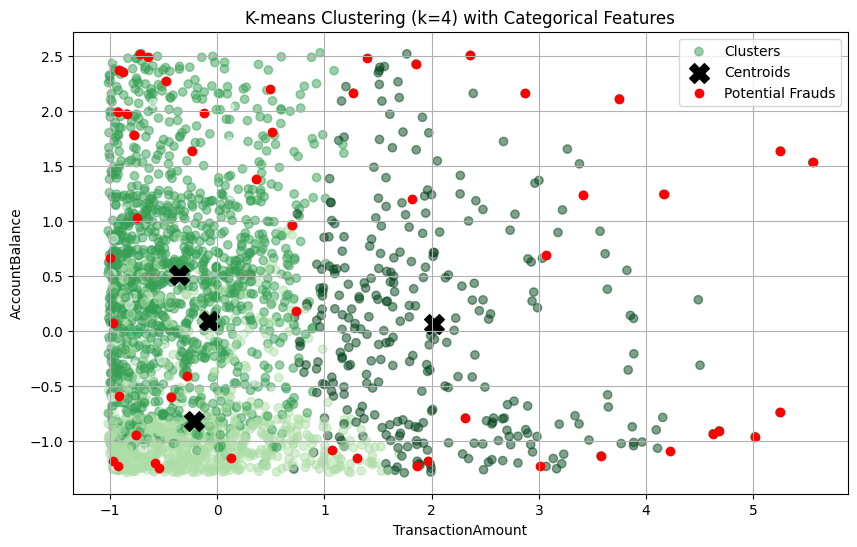

In [ ]:
plt.figure(figsize=(10, 6))

# Plot all data points colored by cluster
plt.scatter(X_num_scaled[:, 0], X_num_scaled[:, 1],
            c=kmeans.labels_, cmap="Greens", alpha=0.5, label='Clusters')

# Plot centroids (projected to the first two dimensions for visualization)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

# Plot potential fraud points
fraud_indices = bank_trans['PotentialFraud']
plt.scatter(X_num_scaled[fraud_indices, 0], X_num_scaled[fraud_indices, 1],
            c='red', marker='o', label='Potential Frauds')

# Add labels and title
plt.xlabel(numerical_features[0])  # TransactionAmount
plt.ylabel(numerical_features[1])  # AccountBalance
plt.title('K-means Clustering (k=4) with Categorical Features')
plt.legend()
plt.grid(True)
plt.show()